# Nonlinearly coupled oscillators


$$ \begin{cases} \dot{q}_1 = p_1 \qquad & \dot{p}_1 = -q_1 - \varepsilon \partial_{q_1} U(q_1,q_2) \\ \dot{q}_2 = \varepsilon p_2 \qquad & \dot{p}_2 = -\varepsilon q_2 - \varepsilon \partial_{q_2} U(q_1,q_2)
\end{cases} $$

$$ H_\varepsilon (q_1,q_2,p_1,p_2) = \frac{1}{2} (q_1^2 + p_1^2 ) + \frac{1}{2} \varepsilon (q_2^2 + p_2^2 )  + \varepsilon U(q_1,q_2)    $$

$$ U(q_1,q_2) = q_1 q_2 \sin(2q_1 + 2q_2)$$

In [1]:
import os, glob
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.ndimage import gaussian_filter1d

In [2]:
def compute_H(u, epsilon=0.01):
    v1, v2, x1, x2 = u[..., 0], u[..., 1], u[..., 2], u[..., 3]
    H = 0.5 * (v1**2 + v2**2 / epsilon) + 0.5 * (x1**2 + x2**2 * epsilon) + epsilon * x1 * x2 * np.sin(2*(x1 + x2))
    return H

def compute_energies(u, epsilon=0.01):
    v1, v2, x1, x2 = u[..., 0], u[..., 1], u[..., 2], u[..., 3]
    K1 = 0.5 * v1**2
    K2 = 0.5 * v2**2 / epsilon
    V1 = 0.5 * x1**2
    V2 = 0.5 * x2**2 * epsilon
    V12 = epsilon * x1 * x2 * np.sin(2*(x1 + x2))
    return {
        "H": K1+K2+V1+V2+V12, 
        "K1+V1": K1+V1, 
        "K2+V2": K2+V2, 
        "K2+V2+V12": K2+V2+V12,
        # "K1": K1, 
        # "K2": K2, 
        # "V1": V1, 
        # "V2": V2, 
        "V12": V12}

def compute_traj_error(sol, ref_sol, epsilon=0.01):
    # Rescale the data: p2 = v2 * m2 = v2 / epsilon
    sol *= np.array([1., 1/epsilon, 1., 1.])
    ref_sol *= np.array([1., 1/epsilon, 1., 1.])
    abs_err = np.linalg.norm(sol - ref_sol, axis=-1)
    rel_err = abs_err / np.linalg.norm(ref_sol, axis=-1)
    return abs_err, rel_err

def compute_traj_error_oscillator1(sol, ref_sol):
    sol = sol[..., (0, 2)]
    ref_sol = ref_sol[..., (0, 2)]
    abs_err = np.linalg.norm(sol - ref_sol, axis=-1)
    rel_err = abs_err / np.linalg.norm(ref_sol, axis=-1)
    return abs_err, rel_err

def compute_traj_error_oscillator2(sol, ref_sol, epsilon=0.01):
    # Rescale the data: p2 = v2 * m2 = v2 / epsilon
    sol *= np.array([1., 1/epsilon, 1., 1.])
    ref_sol *= np.array([1., 1/epsilon, 1., 1.])
    sol = sol[..., (1, 3)]
    ref_sol = ref_sol[..., (1, 3)]
    abs_err = np.linalg.norm(sol - ref_sol, axis=-1)
    rel_err = abs_err / np.linalg.norm(ref_sol, axis=-1)
    return abs_err, rel_err

def compute_traj_error_elementwise(sol, ref_sol, epsilon=0.01, idx=0):
    # Rescale the data: p2 = v2 * m2 = v2 / epsilon
    sol *= np.array([1., 1/epsilon, 1., 1.])
    ref_sol *= np.array([1., 1/epsilon, 1., 1.])
    abs_err = np.abs(sol[..., idx] - ref_sol[..., idx])
    rel_err = abs_err / np.abs(ref_sol[..., idx])
    return abs_err, rel_err

def compute_H_error(sol, ref_sol, epsilon=0.01):
    H = compute_H(sol, epsilon)
    ref_H = compute_H(ref_sol, epsilon)
    abs_err = np.abs(H - ref_H)
    rel_err = abs_err / np.abs(ref_H)
    return abs_err, rel_err

def load_data(filepath, dt=0.05):

    df = pd.read_csv(filepath)
    u = df.values
    t = np.arange(0, len(u)*dt, dt)
    print(u.shape)
    
    return u, t

In [3]:
def compute_grad_H(u, epsilon=0.01):
    """
    dH/dp1 = p1
    dH/dp2 = epsilon * p2 
    dH/dq1 = q1 + epsilon * dU/dq1
    dH/dq2 = epsilon * q2 + epsilon * dU/dq2 
    """
    v1, v2, x1, x2 = u[..., 0], u[..., 1], u[..., 2], u[..., 3]
    p1, p2, q1, q2 = v1, v2/epsilon, x1, x2

    dUdq1 = q2 * np.sin(2*q1+2*q2) + q1 * q2 * 2 * np.cos(2*q1+2*q2)
    dUdq2 = q1 * np.sin(2*q1+2*q2) + q1 * q2 * 2 * np.cos(2*q1+2*q2)

    dHdp1 = p1
    dHdp2 = epsilon * p2
    dHdq1 = q1 + epsilon * dUdq1
    dHdq2 = epsilon * q2 + epsilon * dUdq2

    return np.stack([dHdp1, dHdp2, dHdq1, dHdq2], axis=-1)

In [4]:
def smooth_data(data, sigma=10):
    """
    Smooth the data using a Gaussian filter.
    Args:
        data (np.array): The input data array to smooth.
        sigma (int): The standard deviation for Gaussian kernel.
    Returns:
        np.array: Smoothed data.
    """
    return gaussian_filter1d(data, sigma=sigma)

In [53]:
def plot_phase_space(u_list, indices=None, linestyles=None, legend_labels=None, axis_labels=None, titles=None, 
                     figsize=(9, 3), show_legend=False, save_path=None):
    
    if linestyles is None:
        linestyles = ['-'] * len(u_list)  # Default linestyle for all plots
    
    if legend_labels is None:
        legend_labels = ['Trajectory {}'.format(i+1) for i in range(len(u_list))]  # Default labels for legends

    if axis_labels is None:
        # axis_labels = [('$x_1$', '$v_1$'), ('$x_2$', '$v_2$')]  # Default axis labels
        axis_labels = [('$q_1$', '$p_1$'), ('$q_2$', '$p_2$')]

    if titles is None:
        titles = ['Oscillator 1', 'Oscillator 2']  # Default titles for subplots

    fig, axes = plt.subplots(1, 2, figsize=figsize, layout='constrained')  # Use plt.subplots to manage multiple axes

    lines = []  # List to hold the line objects for the legend
    for u, linestyle, legend_label in zip(u_list, linestyles, legend_labels):
        if indices is None:
            indices = np.arange(len(u))
        u = u / np.array([1., 0.01, 1., 1.])  # Rescale the data: p2 = v2 * m2 = v2 / epsilon
        # Plot on each subplot
        line1, = axes[0].plot(u[indices, 2], u[indices, 0], linestyle, lw=1, label=legend_label)
        axes[1].plot(u[indices, 3], u[indices, 1], linestyle, lw=1)
        lines.append(line1)  # Append the line object for the legend

    # Set labels and titles for each subplot
    axes[0].set_xlabel(axis_labels[0][0])
    axes[0].set_ylabel(axis_labels[0][1])
    axes[0].set_title(titles[0])

    axes[1].set_xlabel(axis_labels[1][0])
    axes[1].set_ylabel(axis_labels[1][1])
    axes[1].set_title(titles[1])

    if show_legend:
        # Place a single legend outside the right of the subplots
        fig.legend(lines, legend_labels, loc='outside center right', borderaxespad=0.1)
        # plt.subplots_adjust(right=0.85)  # Adjust the right boundary of the subplots to make room for the legend

    # plt.tight_layout()

    if save_path:
        plt.savefig(save_path, format='png', dpi=300)  # Save the figure to the specified path
        print(f"Figure saved as '{save_path}'")
    else:
        plt.show()

def plot_u_vs_t(u, t, indices=None):

    if indices is None:
        indices = np.arange(len(u))

    plt.figure(figsize=(12, 10))

    plt.subplot(4, 1, 1)
    plt.plot(t[indices], u[indices, 0], "-", lw=1)
    plt.xlabel("t")
    plt.ylabel("v1")

    plt.subplot(4, 1, 2)
    plt.plot(t[indices], u[indices, 1], "-", lw=1)
    plt.xlabel("t")
    plt.ylabel("v2")

    plt.subplot(4, 1, 3)
    plt.plot(t[indices], u[indices, 2], "-", lw=1)
    plt.xlabel("t")
    plt.ylabel("x1")

    plt.subplot(4, 1, 4)
    plt.plot(t[indices], u[indices, 3], "-", lw=1)
    plt.xlabel("t")
    plt.ylabel("x2")

    plt.tight_layout()
    plt.show()

def plot_energies_vs_t(u, t, indices=None, epsilon=0.01):
    
    if indices is None:
        indices = np.arange(len(u))
        
    energies = compute_energies(u, epsilon)
    
    keys = list(energies.keys())
    n_subplots = len(keys)

    plt.figure(figsize=(12, n_subplots*2))

    for i in range(n_subplots):
        plt.subplot(n_subplots, 1, i+1)
        plt.plot(t[indices], energies[keys[i]][indices], "-", lw=1)
        plt.xlabel("t")
        plt.ylabel(keys[i])

    plt.tight_layout()
    plt.show()

## Compute and visualize $(q_2, p_2)$ level sets

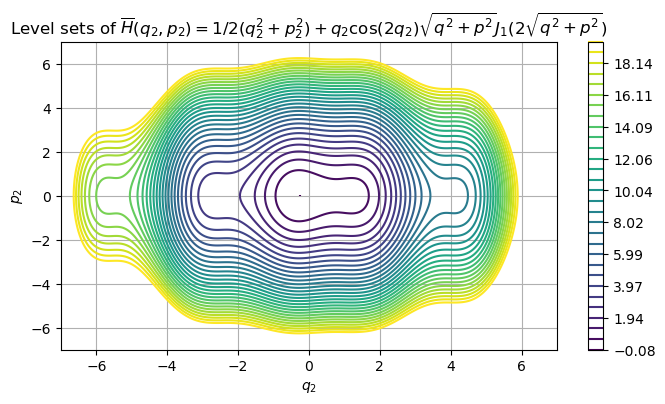

In [6]:
from scipy.special import j1

def averaged_hamiltonian(q2, p2, q, p):
    r = np.sqrt(q**2 + p**2)
    fac = r * j1(2*r)
    return 0.5 * (q2**2 + p2**2) + q2 * np.cos(2 * q2) * fac

# Create a grid of (q2, p2) values
q2 = np.linspace(-7, 7, 400)
p2 = np.linspace(-7, 7, 400)
Q, P = np.meshgrid(q2, p2)

# Calculate H_bar for each (q2, p2) pair
H = averaged_hamiltonian(Q, P, q=1.5, p=0)

# Plot the level sets
plt.figure(figsize=(8, 4))
levels = np.linspace(H.min(), H.max()-30, 30)
# levels = [0., 0.084, 0.171, 0.222, 0.288, 0.335, 0.414, 4., 10.]
contour = plt.contour(Q, P, H, levels=levels, cmap='viridis')
plt.colorbar(contour)
plt.title('Level sets of $\overline{H}(q_2, p_2) = 1/2 (q_2^2 + p_2^2) + q_2 \cos(2q_2) \sqrt{q^2 + p^2} J_1(2\sqrt{q^2 + p^2})$')
plt.xlabel('$q_2$')
plt.ylabel('$p_2$')
plt.grid(True)
plt.show()

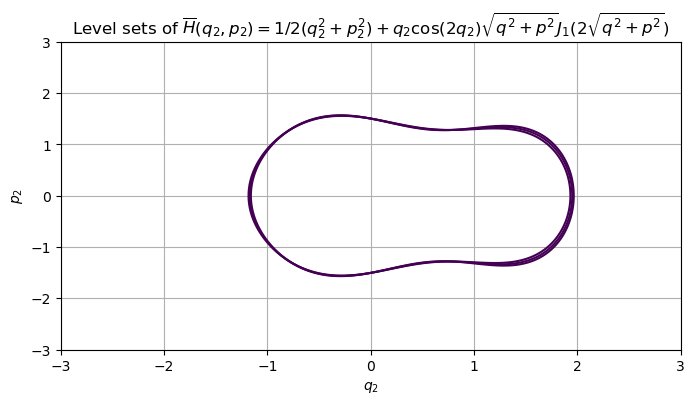

In [7]:
E = 1.129

q2 = np.linspace(-3, 3, 400)
p2 = np.linspace(-3, 3, 400)
Q, P = np.meshgrid(q2, p2)

plt.figure(figsize=(8, 4))

for (q, p) in [(1.5, 0), (-1.45, 0), (1., 0)]: 
    H = averaged_hamiltonian(Q, P, q=q, p=p)
    contour = plt.contour(Q, P, H, levels=[E], cmap='viridis')
    # plt.colorbar(contour)
plt.title('Level sets of $\overline{H}(q_2, p_2) = 1/2 (q_2^2 + p_2^2) + q_2 \cos(2q_2) \sqrt{q^2 + p^2} J_1(2\sqrt{q^2 + p^2})$')
plt.xlabel('$q_2$')
plt.ylabel('$p_2$')
plt.grid(True)
plt.show()

## Compare trajectories with different initial states

In [8]:
from scipy.optimize import fsolve

def find_unknown(H, target_H, knowns, unknown_var):
    """
    Find the unknown variable in the equation H(v1, v2, x1, x2) = target_H.

    Args:
    - H (callable): The function H(v1, v2, x1, x2).
    - target_H (float): The known value of H.
    - knowns (dict): A dictionary with keys as variable names and values as their values. Should contain exactly three items.
    - unknown_var (str): The name of the unknown variable (one of 'v1', 'v2', 'x1', 'x2').

    Returns:
    - float: The computed value of the unknown variable that makes H equal to target_H.
    """
    # Check input validity
    assert len(knowns) == 3 and unknown_var not in knowns, "There must be exactly three known variables."

    # Define the function to find the root
    def func(unknown):
        vars = knowns.copy()
        vars[unknown_var] = unknown[0]
        inputs = np.array([vars['v1'], vars['v2'], vars['x1'], vars['x2']])
        return H(inputs) - target_H

    # Initial guess for the unknown
    initial_guess = [0.1]

    # Solve for the unknown
    solution = fsolve(func, initial_guess)
    error = func(solution)

    return solution[0], error

In [39]:
# Known values and target
target_value = compute_H(np.array([[0.0, 0.0, 1.5, 1.5]]), epsilon=0.01)[0]
known_values = {"v1": 1.0, "x1": 0.0, "x2": 0.0}
print(f"Target value of H is: {target_value}")
print(f"Known values are: {known_values}")

# Find unknown 
unknown_var = "v2"
result, error = find_unknown(lambda u: compute_H(u, epsilon=0.01), target_value, known_values, unknown_var)
print(f"The value of {unknown_var} that satisfies the equation is: {result}")
print(f"The error (residual) of the solution is: {error}")

Target value of H is: 1.1299631512905242
Known values are: {'v1': 1.0, 'x1': 0.0, 'x2': 0.0}
The value of v2 that satisfies the equation is: 0.11224643881126242
The error (residual) of the solution is: -2.220446049250313e-16


In [9]:
# Define state space points [v1, v2, x1, x2]
points = np.array(
    [
     [0.0, 0.0, 1.5, 0.0],
     [0.0, 0.0, 1.5, 0.15],
     [0.0, 0.0, 1.5, 0.3],
     [0.0, 0.0, 1.5, 0.4],
     [0.0, 0.0, 1.5, 1.0],
     [0.0, 0.0, 1.5, 1.45],
     [0.0, 0.0, 1.5, 1.55],
     [0.0, 0.0, 1.5, 4.],
     [0.0, 0.0, 1.5, 5.]
     ])

points = np.array(
    [[0.0, 0.0, 1.5, 1.5],
     [0.0, 0.0, -1.45433, 5.0],
     [0.0, 0.0, 1.0, 11.45256],
     ])

print(compute_energies(points, epsilon=0.01))
# print(compute_energies(points, epsilon=0.001)['H'])
# print(compute_energies(points, epsilon=0.01)['H'])
# print(compute_energies(points, epsilon=0.1)['H'])
# print(compute_energies(points, epsilon=1.)['H'])

{'H': array([1.12996315, 1.12996286, 1.12996172]), 'K1+V1': array([1.125     , 1.05753787, 0.5       ]), 'K2+V2': array([0.01125   , 0.125     , 0.65580565]), 'K2+V2+V12': array([0.00496315, 0.07242498, 0.62996172]), 'V12': array([-0.00628685, -0.05257502, -0.02584393])}


### temp

(40001, 4)
(40001, 4)
Initial state: [0.  0.  1.5 1.5]
H = 1.1299631512905242


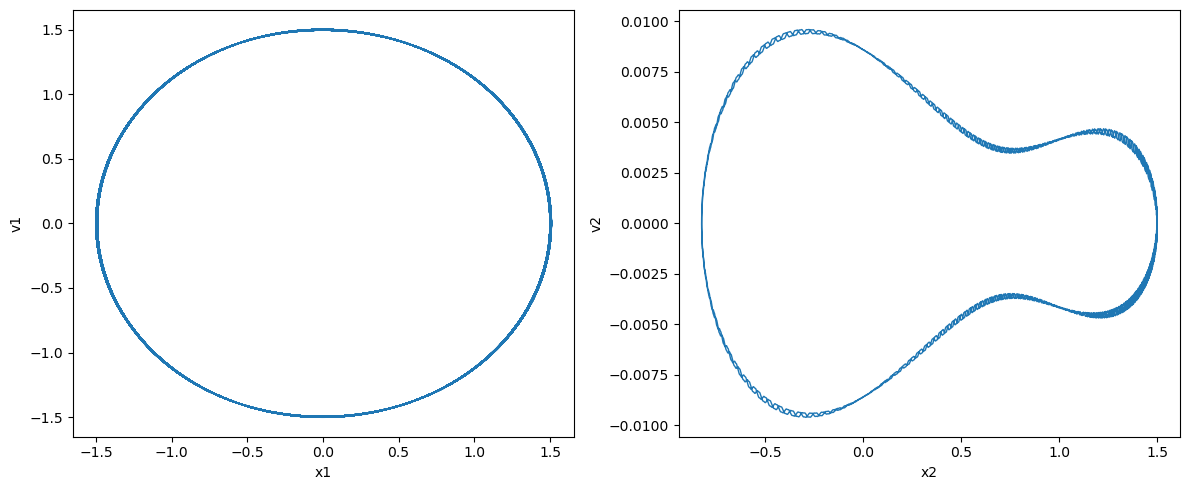

Initial state: [ 0.       0.       1.      11.45256]
H = 1.129961719857544


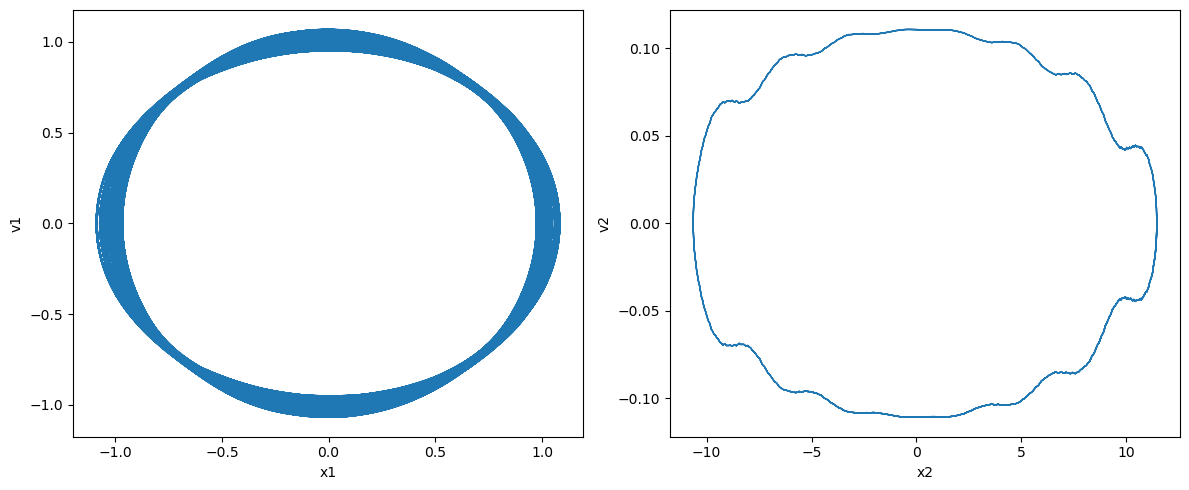

In [44]:
filepath1 = "/workspace/projects_rui/learnsolnmap/out/nco/202405091928/ref/k=0/u.csv"
filepath2 = "/workspace/projects_rui/learnsolnmap/out/nco/202405301406/ref/k=0/u.csv"

u_ref1, t_ref1 = load_data(filepath1, dt=0.05)
u_ref2, t_ref2 = load_data(filepath2, dt=0.05)

print("Initial state:", u_ref1[0])
print("H =", compute_H(u_ref1[0]))
plot_phase_space(u_ref1, np.arange(len(u_ref1))[::1], linestyle="-")

print("Initial state:", u_ref2[0])
print("H =", compute_H(u_ref2[0]))
plot_phase_space(u_ref2, np.arange(len(u_ref2))[::1], linestyle="-")

grad_H1 = compute_grad_H(u_ref1)
grad_H2 = compute_grad_H(u_ref2)

In [63]:
grad_H1[indices_ref][:, (0, 1)]

array([[ 0.00000000e+00,  0.00000000e+00],
       [ 1.42079892e+00, -1.41363346e-04],
       [ 9.23036752e-01, -5.52935884e-04],
       [-8.52933815e-01, -1.37665514e-03],
       [-1.44415562e+00, -1.77819598e-03],
       [-8.55163424e-02, -1.91940741e-03],
       [ 1.39299624e+00, -1.99956421e-03],
       [ 9.85902843e-01, -2.33584356e-03],
       [-7.86818590e-01, -3.03787225e-03],
       [-1.46049288e+00, -3.34903372e-03],
       [-1.56417248e-01, -3.43332825e-03],
       [ 1.36673692e+00, -3.42351690e-03],
       [ 1.03112628e+00, -3.63084941e-03],
       [-7.38571643e-01, -4.13008517e-03],
       [-1.46925709e+00, -4.30720152e-03],
       [-1.97061185e-01, -4.31284910e-03],
       [ 1.35109232e+00, -4.23334190e-03],
       [ 1.04883784e+00, -4.30806906e-03],
       [-7.23050209e-01, -4.58393735e-03],
       [-1.47026527e+00, -4.62991422e-03],
       [-1.94085167e-01, -4.57631834e-03],
       [ 1.35422835e+00, -4.47827203e-03],
       [ 1.03144578e+00, -4.45614410e-03],
       [-7.

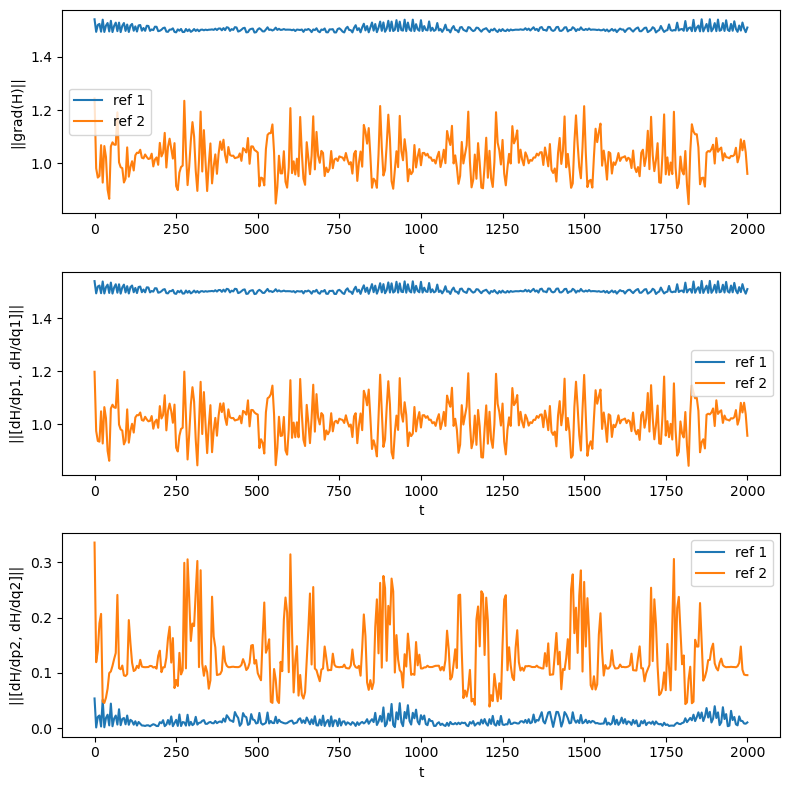

In [69]:
indices_ref = np.arange(len(u_ref1))[::100]
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

plt.figure(figsize=(8, 8))
plt.subplot(3, 1, 1)
plt.plot(t_ref1[indices_ref], np.linalg.norm(grad_H1[indices_ref], axis=-1), 
         "-", c=colors[0], label="ref 1")
plt.plot(t_ref2[indices_ref], np.linalg.norm(grad_H2[indices_ref], axis=-1), 
         "-", c=colors[1], label="ref 2")
plt.xlabel("t")
plt.ylabel("||grad(H)||")
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(t_ref1[indices_ref], np.linalg.norm(grad_H1[indices_ref][:, (0, 2)], axis=-1), 
         "-", c=colors[0], label="ref 1")
plt.plot(t_ref2[indices_ref], np.linalg.norm(grad_H2[indices_ref][:, (0, 2)], axis=-1), 
         "-", c=colors[1], label="ref 2")
plt.xlabel("t")
plt.ylabel("||[dH/dp1, dH/dq1]||")
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(t_ref1[indices_ref], np.linalg.norm(grad_H1[indices_ref][:, (1, 3)], axis=-1), 
         "-", c=colors[0], label="ref 1")
plt.plot(t_ref2[indices_ref], np.linalg.norm(grad_H2[indices_ref][:, (1, 3)], axis=-1), 
         "-", c=colors[1], label="ref 2")
plt.xlabel("t")
plt.ylabel("||[dH/dp2, dH/dq2]||")

plt.legend()
plt.tight_layout()
plt.show()

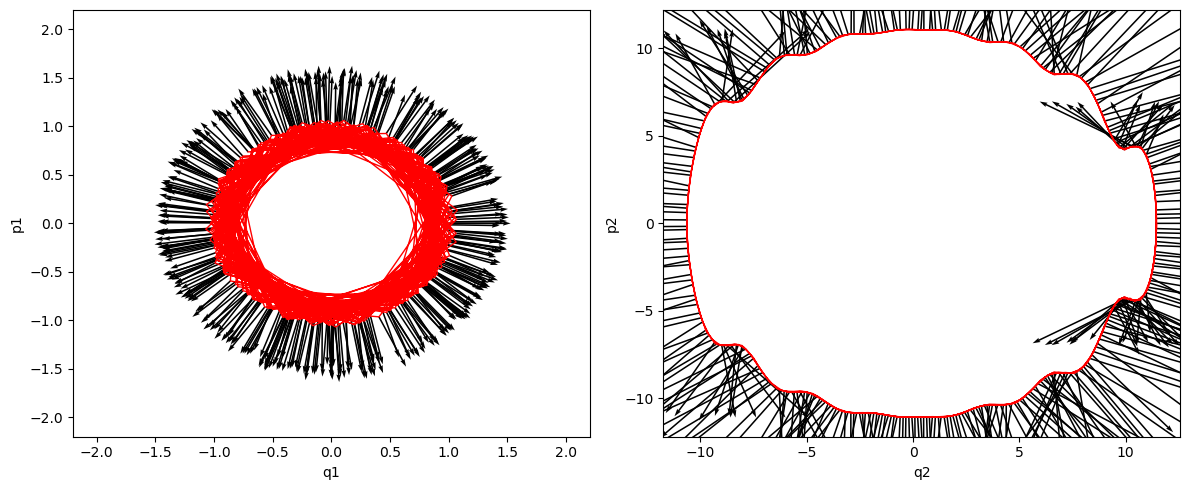

In [58]:
epsilon = 0.01
u_ref = u_ref2 
grad_H = grad_H2

indices_ref = np.arange(len(u_ref1))[::100]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(u_ref[indices_ref, 2], u_ref[indices_ref, 0], "-", lw=1, color="r")
plt.quiver(u_ref[indices_ref, 2], u_ref[indices_ref, 0], 
            grad_H[indices_ref, 2], grad_H[indices_ref, 0], scale=10)
plt.xlim(-2.2, 2.2)
plt.ylim(-2.2, 2.2)
plt.xlabel("q1")
plt.ylabel("p1")
# plt.legend()

plt.subplot(1, 2, 2)
plt.plot(u_ref[indices_ref, 3], u_ref[indices_ref, 1]/epsilon, "-", lw=1, color="r")
plt.quiver(u_ref[indices_ref, 3], u_ref[indices_ref, 1]/epsilon, 
            grad_H[indices_ref, 3], grad_H[indices_ref, 1], scale=0.5)
# plt.xlim(-2., 2)
# plt.ylim(-0.018, 0.018)
plt.xlabel("q2")
plt.ylabel("p2")
# plt.legend()

plt.tight_layout()
plt.show()

### Load reference trajectories

In [66]:
filepath_list = [
    # "/workspace/projects_rui/learnsolnmap/out/nco/202405091738/ref/k=0/u.csv",
    "/workspace/projects_rui/learnsolnmap/out/nco/202405091928/ref/k=0/u.csv",
    "/workspace/projects_rui/learnsolnmap/out/nco/202406151238/ref/k=0/u.csv",
    "/workspace/projects_rui/learnsolnmap/out/nco/202405301406/ref/k=0/u.csv",
    ]
dt = 0.05

# filepath_list = [
#     "/workspace/projects_rui/learnsolnmap/out/nco/202405212307/ref/k=0/u.csv",
#     # "/workspace/projects_rui/learnsolnmap/out/nco/202405221509/ref/k=0/u.csv",
#     # "/workspace/projects_rui/learnsolnmap/out/nco/202405271320/ref/k=0/u.csv",
#     # "/workspace/projects_rui/learnsolnmap/out/nco/202405271715/ref/k=0/u.csv",
#     "/workspace/projects_rui/learnsolnmap/out/nco/202406151309/ref/k=0/u.csv"
#     "/workspace/projects_rui/learnsolnmap/out/nco/202405271736/ref/k=0/u.csv",
#     ]
# dt = 5. 

# labels = ["ref 1", "ref 2", "ref 3"]
# labels = [
#     "init [v1,v2,x1,x2] = [0, 0, 1.5, 1.5]", 
#     "init [v1,v2,x1,x2] = [0, 0, -1.45433, 5.0]",
#     "init [v1,v2,x1,x2] = [0, 0, 1.0, 11.45256]",]
labels = [
    "init $[p_1,p_2,q_1,q_2]$ = [0, 0, 1.5, 1.5]", 
    "init [p1,p2,q1,q2] = [0, 0, -1.45433, 5.0]",
    "init [p1,p2,q1,q2] = [0, 0, 1.0, 11.45256]",]


In [63]:
filepath_list = [
    "/workspace/projects_rui/learnsolnmap/out/nco/202407110236_1/ref/k=0/u.csv",
    "/workspace/projects_rui/learnsolnmap/out/nco/202407110236_2/ref/k=0/u.csv",
    "/workspace/projects_rui/learnsolnmap/out/nco/202407110236_3/ref/k=0/u.csv",
    "/workspace/projects_rui/learnsolnmap/out/nco/202407110236_4/ref/k=0/u.csv",
    "/workspace/projects_rui/learnsolnmap/out/nco/202407110236_5/ref/k=0/u.csv",    
    "/workspace/projects_rui/learnsolnmap/out/nco/202407110236_6/ref/k=0/u.csv",
    "/workspace/projects_rui/learnsolnmap/out/nco/202407110236_7/ref/k=0/u.csv",
    # "/workspace/projects_rui/learnsolnmap/out/nco/202407110236_8/ref/k=0/u.csv",
    # "/workspace/projects_rui/learnsolnmap/out/nco/202407110236_9/ref/k=0/u.csv",
    ]
dt = 0.05

labels = [
    "init [v1,v2,x1,x2] = [0, 0, 1.5, 0.0]", 
    "init [v1,v2,x1,x2] = [0, 0, 1.5, 0.15]", 
    "init [v1,v2,x1,x2] = [0, 0, 1.5, 0.3]", 
    "init [v1,v2,x1,x2] = [0, 0, 1.5, 0.4]", 
    "init [v1,v2,x1,x2] = [0, 0, 1.5, 1.0]", 
    "init [v1,v2,x1,x2] = [0, 0, 1.5, 1.45]", 
    "init [v1,v2,x1,x2] = [0, 0, 1.5, 1.55]", 
    # "init [v1,v2,x1,x2] = [0, 0, 1.5, 4.]", 
    # "init [v1,v2,x1,x2] = [0, 0, 1.5, 5.]", 
    ]


In [67]:
trajs = []

for filepath in filepath_list:

    u_ref, t_ref = load_data(filepath, dt)
    print("Initial state:", u_ref[0])
    print("H =", compute_H(u_ref[0]))
    trajs.append((t_ref, u_ref))

    # plot_phase_space(u_ref, np.arange(len(u_ref))[:20000:1], linestyle="-")
    # plot_u_vs_t(u_ref, t_ref, np.arange(len(u_ref))[::1])
    # plot_energies_vs_t(u_ref, t_ref, indices_ref , epsilon=0.01)

(40001, 4)
Initial state: [0.  0.  1.5 1.5]
H = 1.1299631512905242
(40001, 4)
Initial state: [ 0.       0.      -1.45433  5.     ]
H = 1.1299628556036527
(40001, 4)
Initial state: [ 0.       0.       1.      11.45256]
H = 1.129961719857544


Figure saved as './figs/ref_traj_time5e0.png'


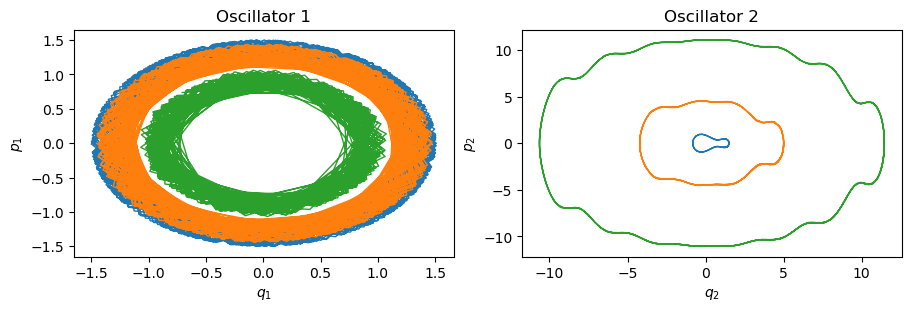

In [68]:
plot_phase_space(
    u_list=[traj[1] for traj in trajs], 
    indices=np.arange(len(trajs[0][1]))[::100], 
    legend_labels=labels,
    show_legend=False, save_path='./figs/ref_traj_time5e0.png')

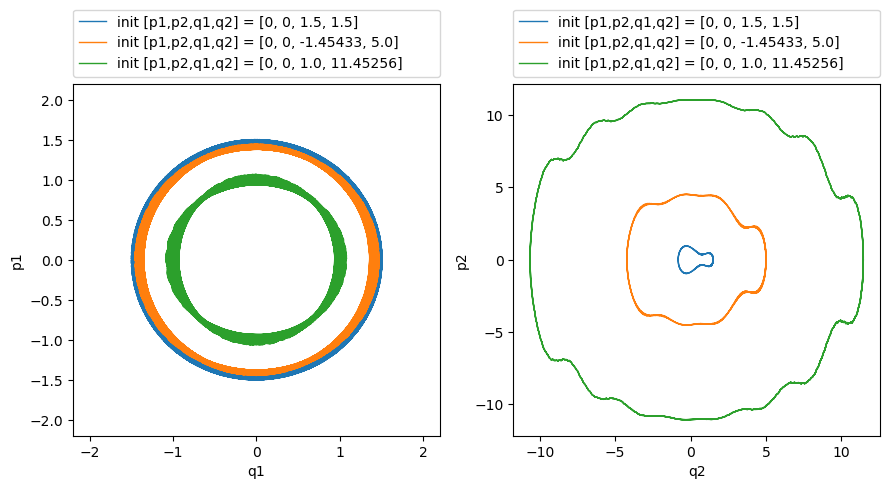

In [12]:
# Phase space plot 

indices = np.arange(len(trajs[0][0]))[:40000:10]

plt.figure(figsize=(9, 5))

plt.subplot(1, 2, 1)
for (t, u), label in zip(trajs, labels):
    plt.plot(u[indices, 2], u[indices, 0], "-", lw=1, label=label)
plt.xlim(-2.2, 2.2)
plt.ylim(-2.2, 2.2)
# plt.xlabel("x1")
# plt.ylabel("v1")
plt.xlabel("q1")
plt.ylabel("p1")
plt.legend(bbox_to_anchor=(0, 1.02, 1, 0.2), loc="lower left",
                mode="expand", borderaxespad=0, ncol=1)

plt.subplot(1, 2, 2)
for (t, u), label in zip(trajs, labels):
    plt.plot(u[indices, 3], u[indices, 1]/0.01, "-", lw=1, label=label)
# plt.xlim(-2., 2)
# plt.ylim(-0.018, 0.018)
# plt.xlabel("x2")
# plt.ylabel("v2")
plt.xlabel("q2")
plt.ylabel("p2")
plt.legend(bbox_to_anchor=(0, 1.02, 1, 0.2), loc="lower left",
                mode="expand", borderaxespad=0, ncol=1)
plt.tight_layout()
# plt.show()
# plt.savefig("./ref_traj.png", dpi=300)

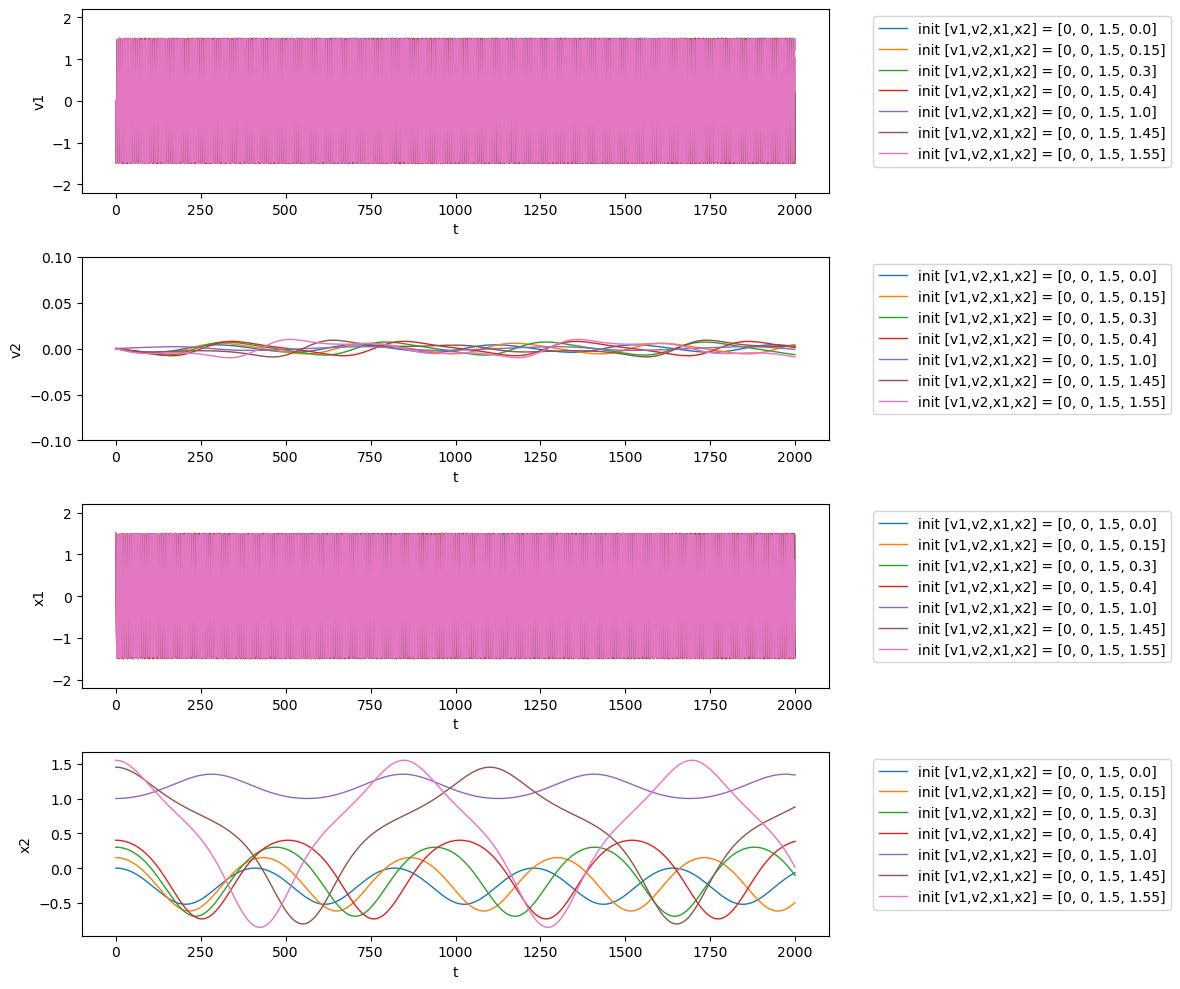

In [15]:
# State variables vs time 

indices = np.arange(len(trajs[0][0]))[:40000:10]

plt.figure(figsize=(12, 10))

plt.subplot(4, 1, 1)
for (t, u), label in zip(trajs, labels):
    plt.plot(t[indices], u[indices, 0], "-", lw=1, label=label)
plt.ylim(-2.2, 2.2)
plt.xlabel("t")
plt.ylabel("v1")
plt.legend(bbox_to_anchor=(1.05, 1.0), loc="upper left")

plt.subplot(4, 1, 2)
for (t, u), label in zip(trajs, labels):
    plt.plot(t[indices], u[indices, 1], "-", lw=1, label=label)
plt.ylim(-0.1, 0.1)
plt.xlabel("t")
plt.ylabel("v2")
plt.legend(bbox_to_anchor=(1.05, 1.0), loc="upper left")

plt.subplot(4, 1, 3)
for (t, u), label in zip(trajs, labels):
    plt.plot(t[indices], u[indices, 2], "-", lw=1, label=label)
plt.ylim(-2.2, 2.2)
plt.xlabel("t")
plt.ylabel("x1")
plt.legend(bbox_to_anchor=(1.05, 1.0), loc="upper left")

plt.subplot(4, 1, 4)
for (t, u), label in zip(trajs, labels):
    plt.plot(t[indices], u[indices, 3], "-", lw=1, label=label)
# plt.ylim(-1., 1.6)
plt.xlabel("t")
plt.ylabel("x2")
plt.legend(bbox_to_anchor=(1.05, 1.0), loc="upper left")

plt.tight_layout()
plt.show()

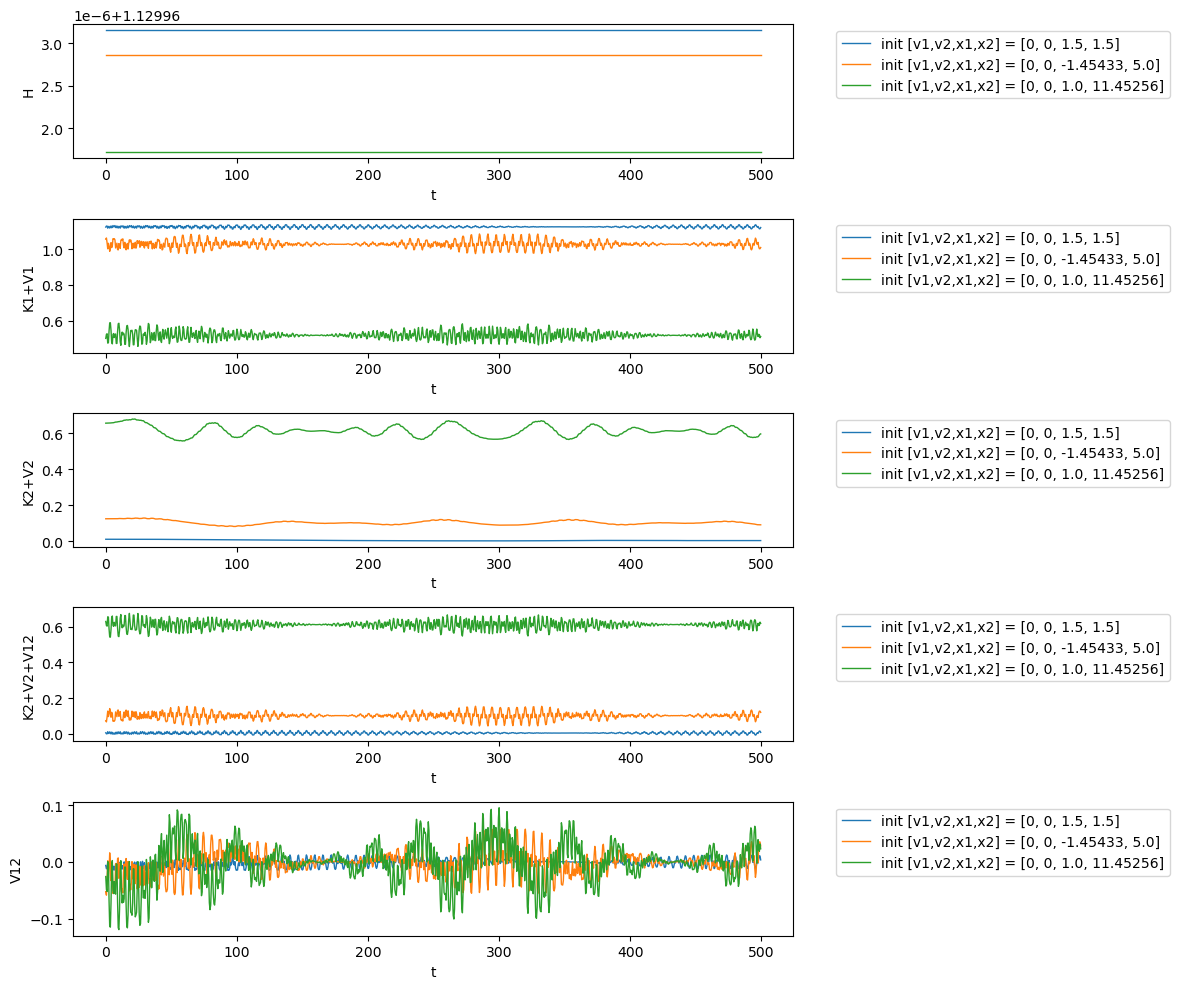

In [56]:
# Energies vs time

indices = np.arange(len(trajs[0][0]))[:10000:10]

energies_of_trajs = [compute_energies(u) for (_, u) in trajs]

keys = list(energies_of_trajs[0].keys())
n_subplots = len(keys)

plt.figure(figsize=(12, n_subplots*2))

for i in range(n_subplots):
    plt.subplot(n_subplots, 1, i+1)
    for j in range(len(trajs)):
        plt.plot(trajs[j][0][indices], energies_of_trajs[j][keys[i]][indices], "-", lw=1, label=labels[j])
    plt.xlabel("t")
    plt.ylabel(keys[i])
    plt.legend(bbox_to_anchor=(1.05, 1.0), loc="upper left")

plt.tight_layout()
plt.show()

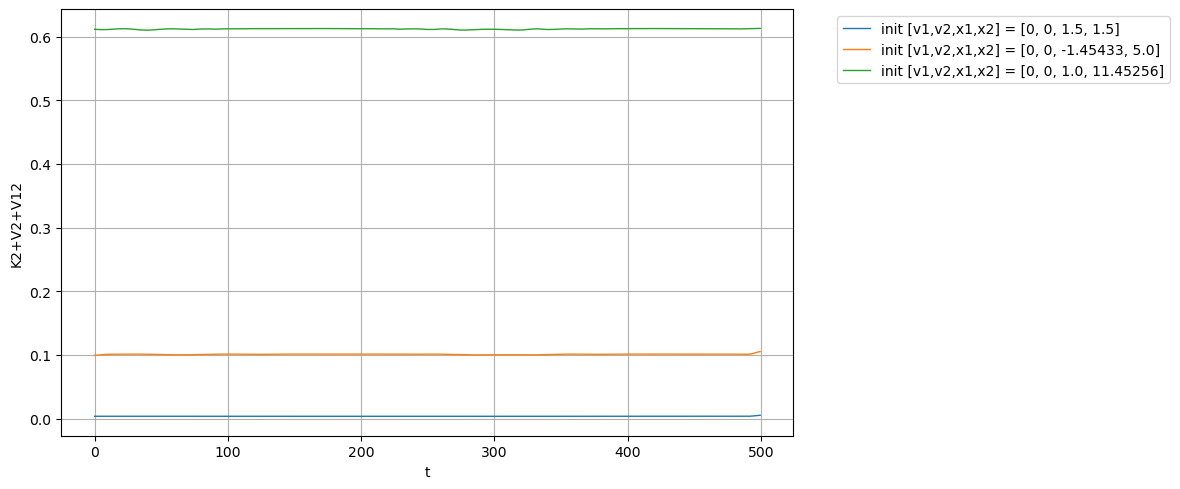

In [57]:
# Oscillator 2 energy vs time

indices = np.arange(len(trajs[0][0]))[:10000:10]

energies_of_trajs = [compute_energies(u) for (_, u) in trajs]

keys = list(energies_of_trajs[0].keys())
n_subplots = 1

plt.figure(figsize=(12, n_subplots*5))

for i in range(n_subplots):
    plt.subplot(n_subplots, 1, i+1)
    for j in range(len(trajs)):
        t = trajs[j][0][indices]
        energy = energies_of_trajs[j]['K2+V2+V12'][indices]
        energy = smooth_data(energy, sigma=8)
        plt.plot(t, energy, "-", lw=1, label=labels[j])
    # plt.ylim(-0.001, 0.005)
    plt.xlabel("t")
    plt.ylabel("K2+V2+V12")
    plt.legend(bbox_to_anchor=(1.05, 1.0), loc="upper left")
    plt.grid(True)

plt.tight_layout()
plt.show()